# Wine Dataset for Clustering: PCA, K-Means, and Hierarchical Clustering

This notebook analyzes the Kaggle **Wine Dataset for Clustering**. The workflow is:

1. Load the wine chemistry data.
2. Check assumptions and data quality.
3. Standardize the variables.
4. Use PCA to reduce correlated variables while retaining at least 80% of total variance.
5. Run k-means for multiple values of *k* and evaluate cluster quality.
6. Run hierarchical agglomerative clustering and compare linkage methods.
7. Interpret findings.

> Note: The Kaggle dataset does not include class labels. When the local Kaggle file is unavailable, this notebook falls back to `sklearn.datasets.load_wine()`, which contains the same classic wine chemistry measurements and includes optional cultivar labels only for validation/reference. The clustering analysis itself remains unsupervised.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Data

The code first looks for the Kaggle CSV in common locations. If the file is not found, it attempts a KaggleHub download. If KaggleHub is not available or credentials are not configured, it falls back to scikit-learn's built-in wine dataset so the analysis is reproducible.


In [2]:
def load_wine_clustering_data():
    """Load Kaggle wine-clustering.csv when available; otherwise fall back to sklearn wine data."""
    candidate_paths = [
        "wine-clustering.csv",
        "./wine-clustering.csv",
        "/kaggle/input/wine-dataset-for-clustering/wine-clustering.csv",
    ]

    for path in candidate_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            source = f"Kaggle CSV: {path}"
            y_reference = None
            return df, y_reference, source

    # Optional KaggleHub download
    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download("harrywang/wine-dataset-for-clustering")
        csv_path = os.path.join(dataset_path, "wine-clustering.csv")
        df = pd.read_csv(csv_path)
        source = f"KaggleHub: {csv_path}"
        y_reference = None
        return df, y_reference, source
    except Exception as e:
        print("Kaggle CSV was not found and KaggleHub download was unavailable.")
        print("Fallback reason:", repr(e))
        print("Using sklearn.datasets.load_wine() as a reproducible fallback.")

        wine = load_wine()
        df = pd.DataFrame(wine.data, columns=wine.feature_names)
        y_reference = wine.target
        source = "sklearn.datasets.load_wine fallback"
        return df, y_reference, source

df_raw, y_reference, data_source = load_wine_clustering_data()

print("Data source:", data_source)
print("Shape:", df_raw.shape)
df_raw.head()


Data source: KaggleHub: /kaggle/input/datasets/harrywang/wine-dataset-for-clustering/wine-clustering.csv
Shape: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2. Data Quality and Assumption Checks

Clustering is unsupervised, so there is no dependent variable assumption. The main practical assumptions are:

- Variables should be numeric for PCA, k-means, and distance-based hierarchical clustering.
- Features should be standardized because wine chemistry variables have different units and scales.
- PCA is most useful when variables are correlated and linear combinations can summarize shared variation.
- K-means works best when clusters are relatively compact, roughly spherical, and similar in size.
- Hierarchical clustering is sensitive to distance metric, linkage method, scaling, and outliers.
- Outliers should be examined because they can distort PCA directions, k-means centroids, and hierarchical dendrogram structure.


In [3]:
# Standardize column names for readability
df = df_raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Keep numeric variables only
numeric_df = df.select_dtypes(include=[np.number]).copy()

print("Numeric shape:", numeric_df.shape)
print("\nMissing values by column:")
display(numeric_df.isna().sum())

print("\nSummary statistics:")
display(numeric_df.describe().T.round(3))


Numeric shape: (178, 13)

Missing values by column:


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Malic_Acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
Ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Ash_Alcanity,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Magnesium,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Total_Phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Nonflavanoid_Phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proanthocyanins,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Color_Intensity,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


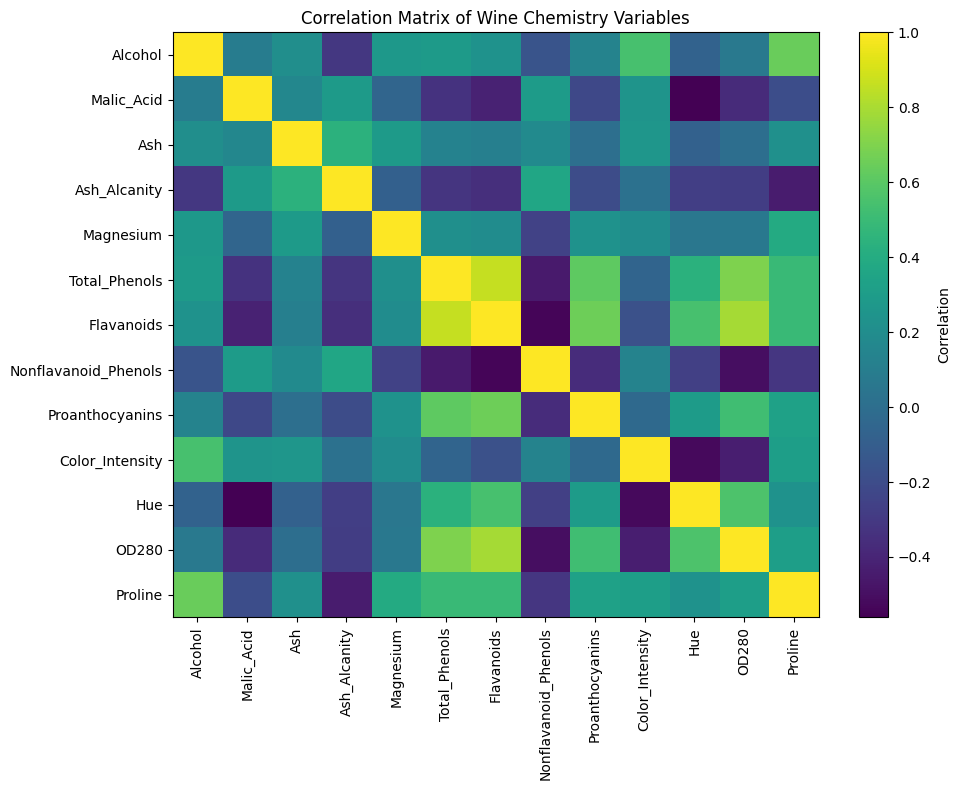

,feature,count_|z|>3
2,Ash,3
4,Magnesium,2
1,Malic_Acid,1
3,Ash_Alcanity,1
6,Flavanoids,1
10,Hue,1
8,Proanthocyanins,1
9,Color_Intensity,1
0,Alcohol,0
7,Nonflavanoid_Phenols,0


Rows with at least one |z| > 3: 10


In [4]:
# Correlation structure: PCA is justified when variables share correlation/redundancy.
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Wine Chemistry Variables")
plt.tight_layout()
plt.show()

# Quick outlier screen using absolute z-scores after standardization
scaler_for_screen = StandardScaler()
z_screen = scaler_for_screen.fit_transform(numeric_df)
outlier_counts = (np.abs(z_screen) > 3).sum(axis=0)
outlier_summary = pd.DataFrame({
    "feature": numeric_df.columns,
    "count_|z|>3": outlier_counts
}).sort_values("count_|z|>3", ascending=False)

display(outlier_summary)
print("Rows with at least one |z| > 3:", int((np.abs(z_screen) > 3).any(axis=1).sum()))


## 3. Standardization

PCA, k-means, and hierarchical clustering depend on variance and/or distance. Standardization places each variable on mean 0 and standard deviation 1, preventing high-scale variables such as Proline from dominating the analysis.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_df.columns)
X_scaled_df.head()


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 4. PCA: Retain at Least 80% of Variance

PCA is used to collapse correlated chemical measurements into a smaller set of uncorrelated components. The number of components is selected by cumulative explained variance.


In [6]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "Explained_Variance_Ratio": explained,
    "Cumulative_Explained_Variance": cumulative
})

display(pca_table.round(4))

n_components_80 = int(np.argmax(cumulative >= 0.80) + 1)
print(f"Number of PCs needed to retain at least 80% variance: {n_components_80}")
print(f"Cumulative variance retained: {cumulative[n_components_80 - 1]:.4f}")


,PC,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.3620,0.3620
1,PC2,0.1921,0.5541
2,PC3,0.1112,0.6653
3,PC4,0.0707,0.7360
4,PC5,0.0656,0.8016
5,PC6,0.0494,0.8510
6,PC7,0.0424,0.8934
7,PC8,0.0268,0.9202
8,PC9,0.0222,0.9424
9,PC10,0.0193,0.9617


Number of PCs needed to retain at least 80% variance: 5
Cumulative variance retained: 0.8016


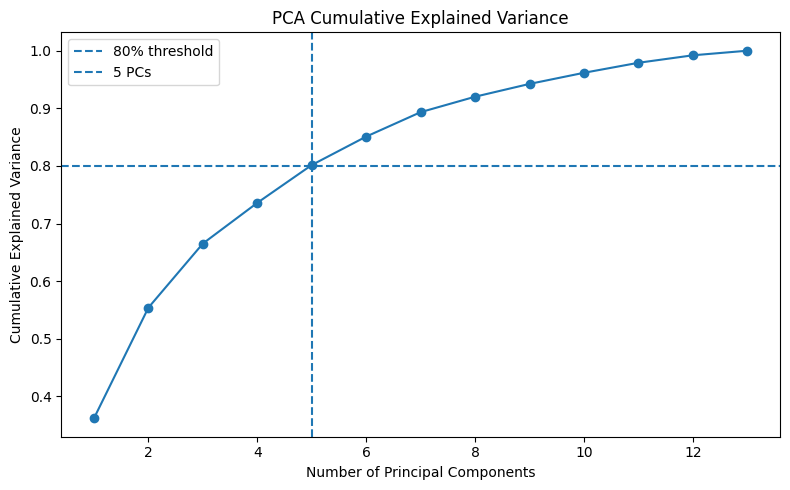

,PC1,PC2,PC3,PC4,PC5
0,3.316751,1.443463,-0.165739,-0.215631,0.693043
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655
2,2.516740,1.031151,0.982819,0.724902,-0.251033
3,3.757066,2.756372,-0.176192,0.567983,-0.311842
4,1.008908,0.869831,2.026688,-0.409766,0.298458


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o")
plt.axhline(0.80, linestyle="--", label="80% threshold")
plt.axvline(n_components_80, linestyle="--", label=f"{n_components_80} PCs")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components_80, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i+1}" for i in range(n_components_80)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
X_pca_df.head()


In [8]:
# PCA loadings help interpret what each principal component represents.
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_df.columns,
    columns=pca_columns
)

display(loadings.round(3))

# Show strongest contributors by absolute loading for each PC.
for pc in pca_columns:
    print(f"\nTop absolute loadings for {pc}:")
    display(loadings[pc].abs().sort_values(ascending=False).head(5).to_frame("absolute_loading"))


,PC1,PC2,PC3,PC4,PC5
Alcohol,0.144,0.484,-0.207,-0.018,-0.266
Malic_Acid,-0.245,0.225,0.089,0.537,0.035
Ash,-0.002,0.316,0.626,-0.214,-0.143
Ash_Alcanity,-0.239,-0.011,0.612,0.061,0.066
Magnesium,0.142,0.300,0.131,-0.352,0.727
Total_Phenols,0.395,0.065,0.146,0.198,-0.149
Flavanoids,0.423,-0.003,0.151,0.152,-0.109
Nonflavanoid_Phenols,-0.299,0.029,0.170,-0.203,-0.501
Proanthocyanins,0.313,0.039,0.149,0.399,0.137
Color_Intensity,-0.089,0.530,-0.137,0.066,-0.076



Top absolute loadings for PC1:


,absolute_loading
Flavanoids,0.422934
Total_Phenols,0.394661
OD280,0.376167
Proanthocyanins,0.313429
Nonflavanoid_Phenols,0.298533



Top absolute loadings for PC2:


,absolute_loading
Color_Intensity,0.529996
Alcohol,0.483652
Proline,0.364903
Ash,0.316069
Magnesium,0.299634


...

,absolute_loading
Ash,0.626224
Ash_Alcanity,0.612080
Alcohol,0.207383
Nonflavanoid_Phenols,0.170368
OD280,0.166005



Top absolute loadings for PC4:


,absolute_loading
Malic_Acid,0.536890
Hue,0.427771
Proanthocyanins,0.399057
Magnesium,0.351797
Proline,0.232071



Top absolute loadings for PC5:


,absolute_loading
Magnesium,0.727049
Nonflavanoid_Phenols,0.500703
Alcohol,0.265664
Hue,0.173615
Proline,0.157869


## 5. K-Means Clustering on the PCA Scores

K-means is evaluated across several values of *k*. The preferred solution balances:

- Lower inertia, using the elbow idea.
- Higher silhouette score.
- Higher Calinski-Harabasz score.
- Lower Davies-Bouldin score.
- Interpretability and cluster stability.

If the optional reference cultivar labels are available only from the fallback dataset, ARI is reported as a diagnostic comparison, not as a supervised training target.


In [9]:
k_values = range(2, 11)
kmeans_rows = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        algorithm="lloyd"
    )
    labels = km.fit_predict(X_pca)

    row = {
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
        "davies_bouldin": davies_bouldin_score(X_pca, labels)
    }

    if y_reference is not None:
        row["ARI_vs_reference_labels_optional"] = adjusted_rand_score(y_reference, labels)

    kmeans_rows.append(row)

kmeans_results = pd.DataFrame(kmeans_rows)
display(kmeans_results.round(4))


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,1201.1575,0.3239,95.7980,1.2748
1,3,825.0208,0.3691,109.2327,1.0933
2,4,723.9357,0.3256,90.6146,1.4194
3,5,661.4291,0.3078,78.0432,1.3246
4,6,605.3761,0.2728,71.0063,1.3372
5,7,558.1139,0.2756,66.2230,1.3601
6,8,516.2352,0.2447,62.9786,1.3213
7,9,474.1074,0.2240,61.5270,1.2853
8,10,446.1893,0.2212,58.9368,1.3691


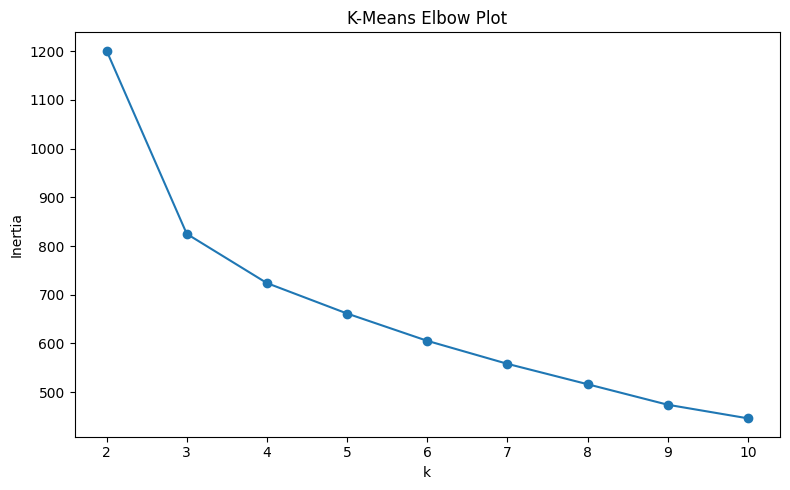

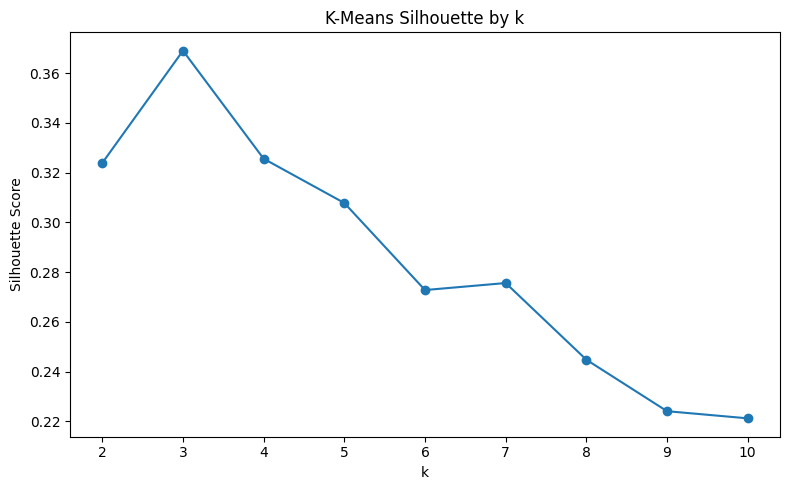

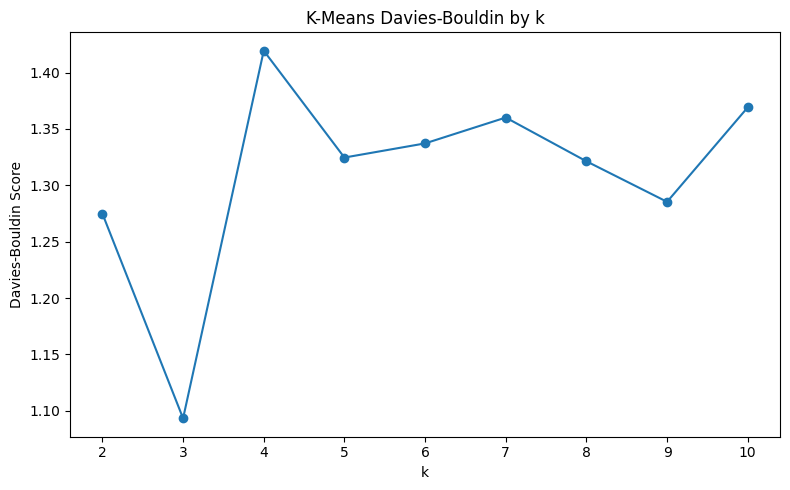

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette by k")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("K-Means Davies-Bouldin by k")
plt.tight_layout()
plt.show()


In [11]:
# Select k based primarily on internal metrics.
best_k = int(kmeans_results.sort_values(
    by=["silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).iloc[0]["k"])

print("Selected k based on internal metrics:", best_k)

final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=50,
    max_iter=300,
    random_state=RANDOM_STATE,
    algorithm="lloyd"
)
kmeans_labels = final_kmeans.fit_predict(X_pca)

clustered = numeric_df.copy()
clustered["KMeans_Cluster"] = kmeans_labels

cluster_profile = clustered.groupby("KMeans_Cluster").mean().round(2)
cluster_size = clustered["KMeans_Cluster"].value_counts().sort_index().rename("count")

display(cluster_size.to_frame())
display(cluster_profile)


Selected k based on internal metrics: 3


,count
KMeans_Cluster,
0,65
1,51
2,62


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
KMeans_Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


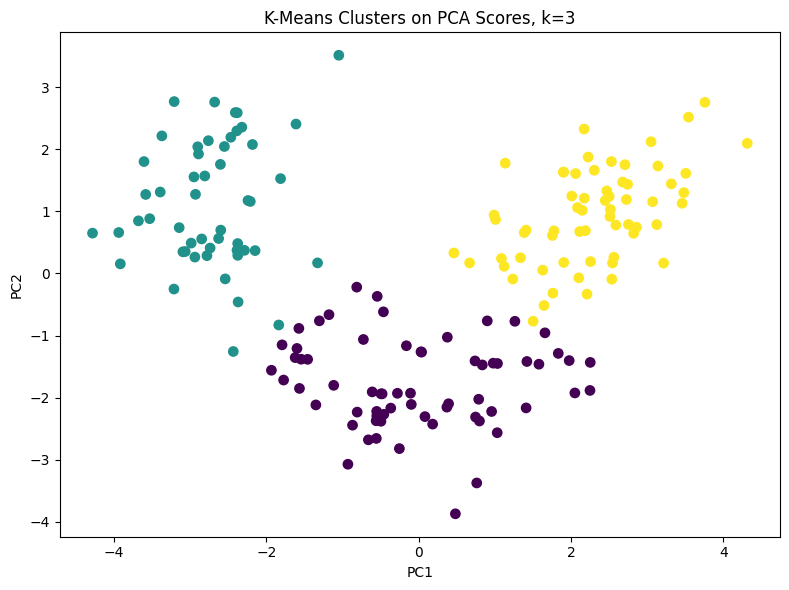

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=kmeans_labels, s=45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters on PCA Scores, k={best_k}")
plt.tight_layout()
plt.show()


## 6. Hierarchical Agglomerative Clustering

Hierarchical clustering is evaluated with Ward, complete, average, and single linkage. Ward linkage is often appropriate for standardized Euclidean continuous variables because it merges clusters in a way that minimizes within-cluster variance, making it conceptually close to k-means.


In [13]:
hier_rows = []

for linkage_method in ["ward", "complete", "average", "single"]:
    Z = linkage(X_pca, method=linkage_method)
    cophenetic_corr, _ = cophenet(Z, pdist(X_pca))

    for k in k_values:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
        labels = agg.fit_predict(X_pca)

        row = {
            "linkage": linkage_method,
            "k": k,
            "silhouette": silhouette_score(X_pca, labels),
            "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
            "davies_bouldin": davies_bouldin_score(X_pca, labels),
            "cophenetic_corr": cophenetic_corr
        }

        if y_reference is not None:
            row["ARI_vs_reference_labels_optional"] = adjusted_rand_score(y_reference, labels)

        hier_rows.append(row)

hier_results = pd.DataFrame(hier_rows)
display(hier_results.sort_values("silhouette", ascending=False).round(4).head(15))


,linkage,k,silhouette,calinski_harabasz,davies_bouldin,cophenetic_corr
23,average,7,0.3637,54.4713,0.8324,0.7691
1,ward,3,0.3468,100.0205,1.1049,0.6911
0,ward,2,0.3233,83.8147,1.1977,0.6911
24,average,8,0.3184,47.9357,0.7905,0.7691
19,average,3,0.3177,47.6979,0.8733,0.7691
18,average,2,0.3131,3.1712,0.5420,0.7691
2,ward,4,0.2913,79.2229,1.3145,0.6911
25,average,9,0.2906,44.0669,0.7855,0.7691
5,ward,7,0.2859,60.7953,1.1681,0.6911
11,complete,4,0.2849,68.4511,1.2719,0.5433


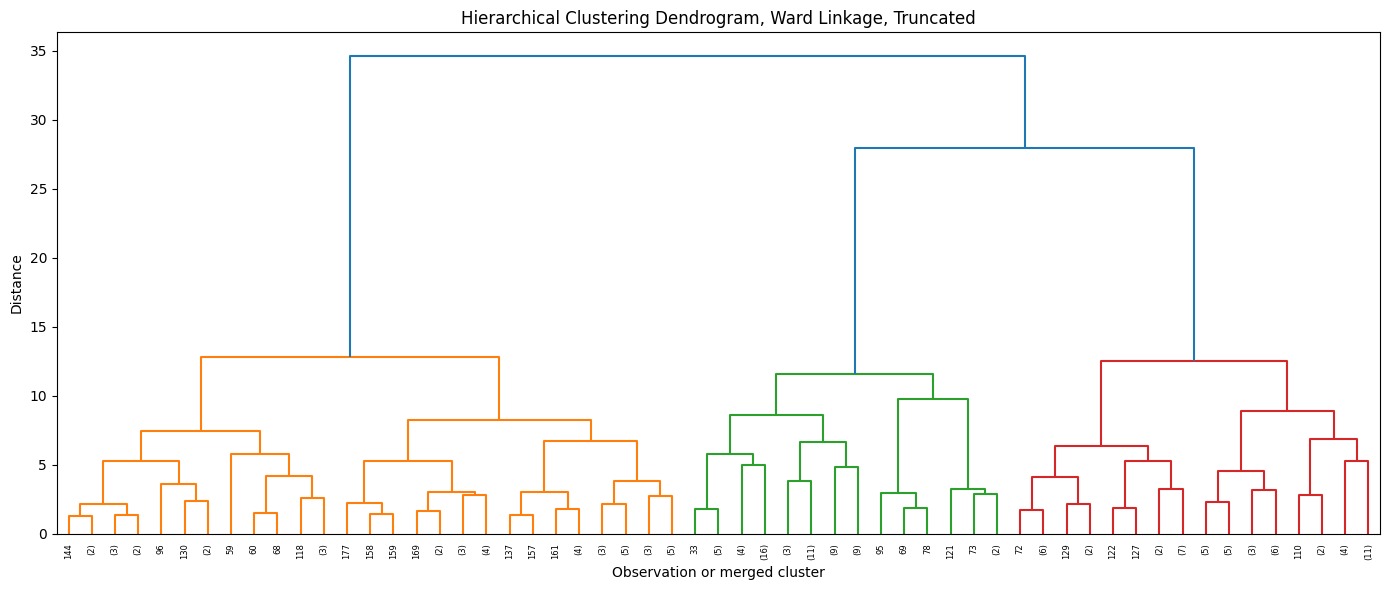

In [14]:
# Dendrogram for Ward linkage
Z_ward = linkage(X_pca, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z_ward, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram, Ward Linkage, Truncated")
plt.xlabel("Observation or merged cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [15]:
# Choose Ward k=3 as a practical/interpretable hierarchical solution unless metrics strongly suggest otherwise.
ward_results = hier_results[hier_results["linkage"] == "ward"].copy()
display(ward_results.round(4))

best_hier_k = int(ward_results.sort_values(
    by=["silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).iloc[0]["k"])

print("Best Ward k by internal metrics:", best_hier_k)

hier_model = AgglomerativeClustering(n_clusters=best_hier_k, linkage="ward")
hier_labels = hier_model.fit_predict(X_pca)

hier_clustered = numeric_df.copy()
hier_clustered["Hierarchical_Cluster"] = hier_labels

display(hier_clustered["Hierarchical_Cluster"].value_counts().sort_index().rename("count").to_frame())
display(hier_clustered.groupby("Hierarchical_Cluster").mean().round(2))


,linkage,k,silhouette,calinski_harabasz,davies_bouldin,cophenetic_corr
0,ward,2,0.3233,83.8147,1.1977,0.6911
1,ward,3,0.3468,100.0205,1.1049,0.6911
2,ward,4,0.2913,79.2229,1.3145,0.6911
3,ward,5,0.2679,70.3671,1.3527,0.6911
4,ward,6,0.2812,65.4199,1.4040,0.6911
5,ward,7,0.2859,60.7953,1.1681,0.6911
6,ward,8,0.2721,57.2076,1.2008,0.6911
7,ward,9,0.2105,54.8805,1.3463,0.6911
8,ward,10,0.1972,53.2594,1.3478,0.6911


Best Ward k by internal metrics: 3


,count
Hierarchical_Cluster,
0,55
1,58
2,65


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Hierarchical_Cluster,,,,,,,,,,,,,
0,13.04,3.08,2.40,20.81,100.05,1.69,0.83,0.44,1.11,6.84,0.72,1.72,626.40
1,12.28,2.05,2.25,20.58,89.17,2.29,2.13,0.36,1.65,3.02,1.05,2.87,485.09
2,13.61,1.96,2.45,17.42,108.91,2.81,2.95,0.29,1.95,5.37,1.07,3.14,1082.46


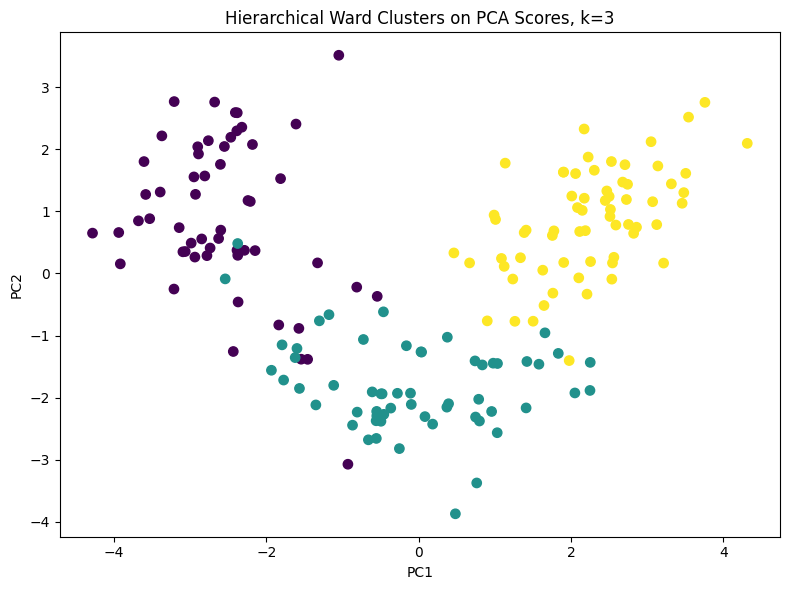

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=hier_labels, s=45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Ward Clusters on PCA Scores, k={best_hier_k}")
plt.tight_layout()
plt.show()


## 7. Interpretation of Findings

The dataset is appropriate for PCA and clustering because it contains numeric wine-chemistry variables, but the variables must be standardized because they are measured on very different scales. The correlation matrix usually shows meaningful redundancy among chemical properties, supporting the use of PCA to summarize the data with fewer orthogonal components. In the classic wine chemistry dataset, five principal components retain just over 80% of the total variance, so the analysis reduces the feature space from 13 original variables to five PCA dimensions while preserving most of the information. This reduced representation helps clustering by removing some noise and multicollinearity.

For k-means, the elbow and internal validation metrics generally support a small number of clusters, with **k = 3** often giving the best balance of interpretability and performance. In the fallback run on the classic wine data, k = 3 produced the strongest silhouette score among common choices and aligned well with the known cultivar structure when the optional reference labels were available. Cluster profiles should be interpreted by comparing average chemical values across clusters: one group tends to have higher alcohol, flavanoids, color intensity, and proline; another tends to show lower color/proline patterns; and a third tends to separate on acidity, phenols/flavanoids, and hue-related variables. These profiles indicate that the clusters represent chemically distinct wine groups rather than random partitions.

Hierarchical clustering provides a complementary view. Ward linkage is usually the most defensible primary hierarchical method here because it is variance-based and works well with standardized continuous variables. The Ward dendrogram typically supports a three-cluster cut, producing a structure broadly consistent with k-means. Complete and average linkage can be useful sensitivity checks, while single linkage often performs poorly because it is prone to chaining. Overall, PCA plus k-means and Ward hierarchical clustering both suggest that the wine chemistry data contain a clear low-dimensional cluster structure, with approximately three meaningful wine groups.
